# EDA (Exploratory Data Analysis)

1.Load datasets

2.Clean data (misssing values,duplicates,types)

3.Treat outliers

4.Univariate & bivariate and multivariate analysis

5.Insights

### Outliers:
A Data point significantly different from other observations in a dataset.

#### How The outliers will come?
1.Measurement errors
2.Data entry mistakes

#### why they are important?
1.They can be errors
2.Effect the dataAnalysis

#### How toidentify the outliers
1.Statistical Methods
----> Interquartile Range (IQR)
----->Z-score
2.Visualization Tech
----->Box plots
----->Scatter plots
----->Histograms

### Univariate analysis- a method that analyzes a single variable to describe its characteristics,find patterns and summarize data.
### It involves Only one variable

### Bivariate analysis-It helps b.w 2 variables .it helps to find if there is any correlation,association
### It invloves 2 variables

### Multivariate analyis-To understand how multiple factors interact and influence each other
#### It involves more than 2
Example:
How our age,income  and education level together influence the purchasing behaviour


# ETL: <Dataset>
1.Load And overview
2.Cleaning the data
3.Uni,Bi,Multi variate
4.Outlier-IQR,Z-Score
5.Feature Engineering 
6.Key Insights


### Feature Engineering :
"Turning raw data into useful features" that helps to improve the performance of machine learning models

In [1]:
# 1.Load Libraries & Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [2]:
#Basic Information & Overview
print("shape of dataset",df.shape)
print(f"\n Data information {df.info}")

#Summary Statistics
df.describe(include='all')



shape of dataset (891, 15)

 Data information <bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing=pd.DataFrame({ 'missing_count':df.isnull().sum(),
                      'missing_percent':(df.isnull().sum()/ len(df))*100})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [9]:
# Handling Missing values

# Fill the numeric missing values with the mean 
df['age']=df['age'].fillna(df['age'].mean())

# Fill categorical values with mode
df['embarked']= df['embarked'].fillna(df['embarked'].mode())

# Drop 'deck' column (too many missing values)
df.drop(columns=['deck'],inplace=True)
print("Missing values after cleaning :\n",df.isnull().sum().sum())

KeyError: "['deck'] not found in axis"

,missing_count,missing_percent
embark_town,2,0.224467
embarked,2,0.224467
sex,0,0.000000
age,0,0.000000
survived,0,0.000000
pclass,0,0.000000
parch,0,0.000000
sibsp,0,0.000000
class,0,0.000000
fare,0,0.000000


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while the dataset clean.

In [10]:
# Duplicate and Data type check

print("Duplicate rows:",df.duplicated().sum())

#Convert some columns to category type
df['class'] = df['class'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

df.info()

Duplicate rows: 111
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(4), object(3)
memory usage: 67.5+ KB


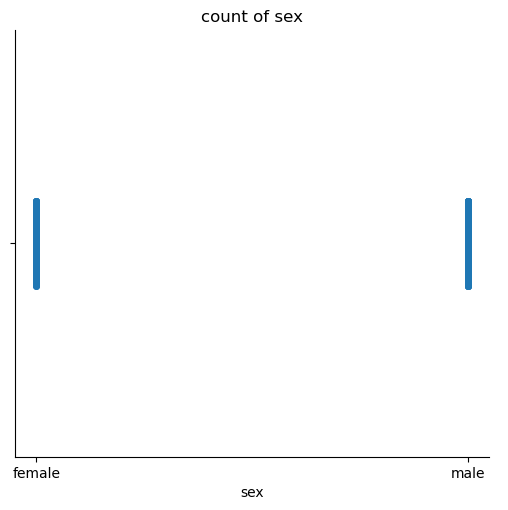

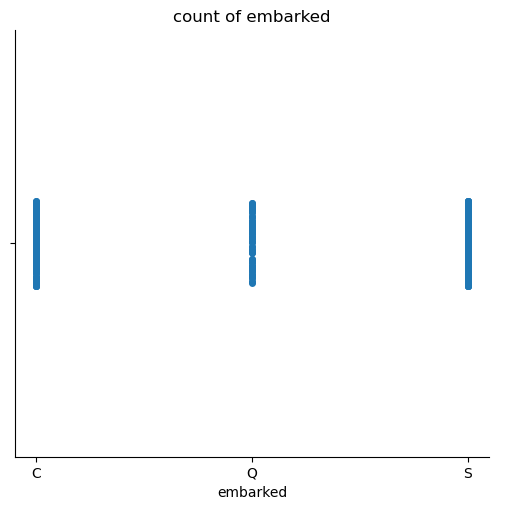

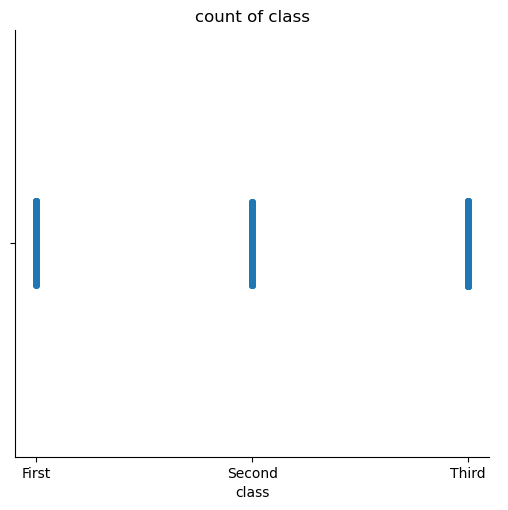

In [ ]:
# univariate
cat_clos=df.select_dtypes('category').columns
for col in cat_clos:
    sns.catplot(x=col,data=df)
    plt.title(f"count of {col}")

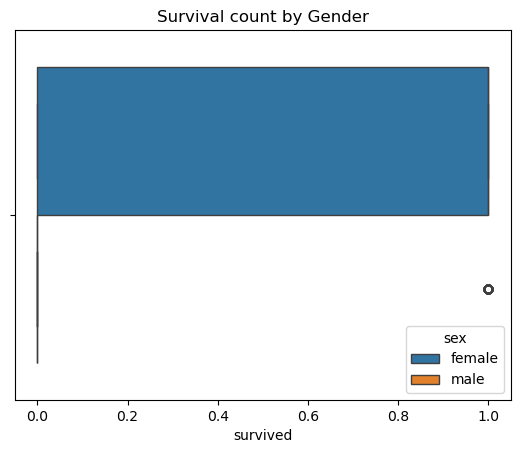

In [14]:
# Bivariate Analysis- Numerical vs categorical
sns.boxplot(x='survived',hue='sex',data=df)
plt.title("Survival count by Gender")
plt.show()



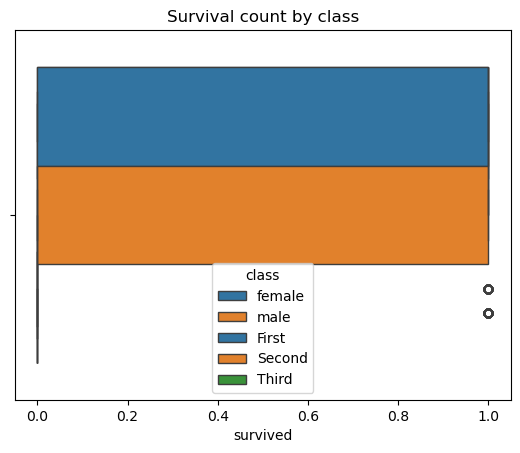

In [15]:
sns.boxplot(x='survived',hue='sex',data=df)
plt.title("Survival count by Gender")
sns.boxplot(x='survived',hue='class',data=df)
plt.title("Survival count by class")
plt.show()

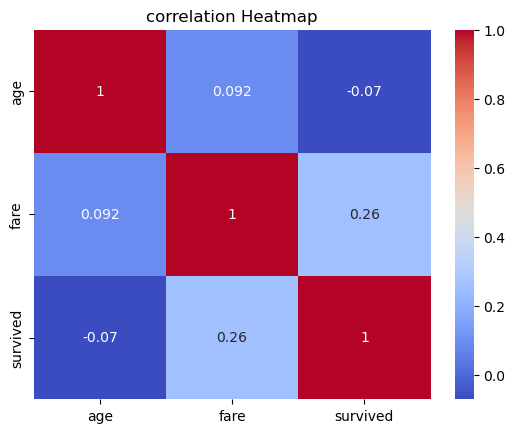

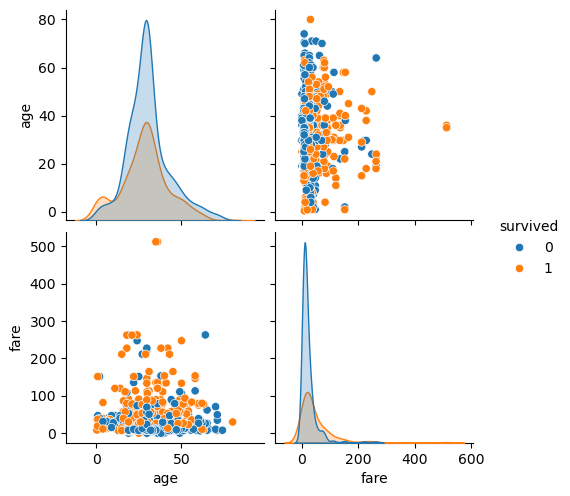

In [18]:
# Correlation and multivariate analysis
corr=df[['age','fare','survived',]].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()

sns.pairplot(df[['age','fare','survived']],hue='survived')
plt.show()

Insights:
1.Fare has a positive correlation with survival

2.Age  shows a slight negative correlation with survival

Number of outliers in fare: 891


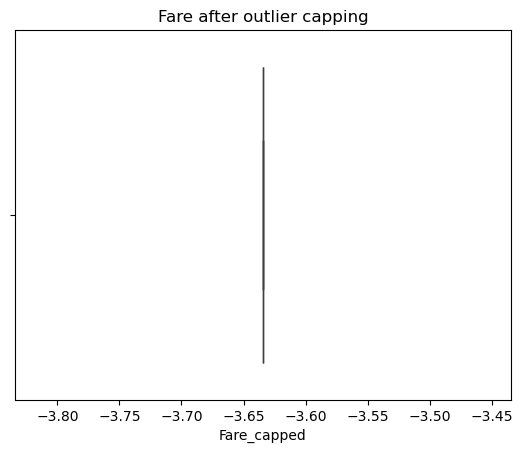

In [20]:
# Outliers Detection using IQR
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5* IQR
upper=Q3-1.5*IQR
outliers=df[(df['fare']<lower)|(df['fare']>upper)]
print("Number of outliers in fare:",len(outliers))

#outliers
df['Fare_capped']=df['fare'].clip(lower,upper)
sns.boxplot(x=df['Fare_capped'])
plt.title("Fare after outlier capping")
plt.show()

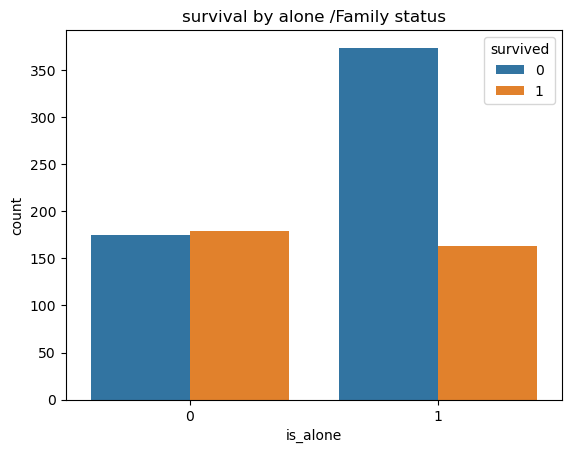

,family_size,is_alone,survived
0,2,0,0
1,2,0,1
2,1,1,1
3,2,0,1
4,1,1,0


In [23]:
#Feature Engineering
# Create new features
df['family_size']= df['sibsp']+df['parch']+ 1
df['is_alone']=(df['family_size']==1).astype(int)

sns.countplot(x='is_alone',hue='survived',data=df)
plt.title("survival by alone /Family status")
plt.show()

df[['family_size','is_alone','survived']].head()



In [24]:
df.to_csv("Titanic_cleaned",index=False)
print("\n Cleaned Titanic data saved as titanic_cleaned.csv")


 Cleaned Titanic data saved as titanic_cleaned.csv


In [ ]:
import os
print(os.getcwd()) 

c:\Users\indun\OneDrive\Desktop\Data_Analysis
